In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
# plt.style.use('ggplot')
plt.style.use("default")

In [53]:
fontdict = {'fontsize':16, 'fontname':'Times New Roman'}
title_fontdict = {'fontsize':20, 'fontweight':'bold','fontname':'Times New Roman'}

In [ ]:
df2 = pd.read_csv('Data/Cleaned/CFW_Monthly_Crime_Count_Cleaned.csv.csv')
df2['Date'] = pd.to_datetime(df2['Date'])
df2.head()

,Date,Crime_Count
0,2016-02-01,4784.0
1,2016-03-01,5248.0
2,2016-04-01,5396.0
3,2016-05-01,5584.0
4,2016-06-01,5328.0


In [28]:
df2.tail()

,Date,Crime_Count
111,2025-05-01,4933.0
112,2025-06-01,4621.0
113,2025-07-01,4914.0
114,2025-08-01,4965.0
115,2025-09-01,4793.0


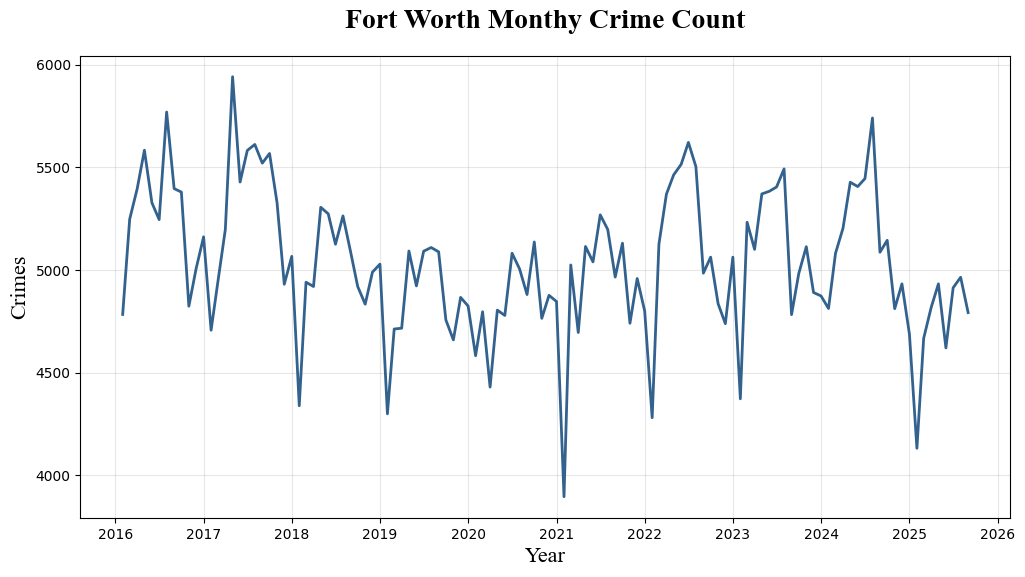

In [41]:
plt.figure(figsize=(12,6), )
plt.plot(df2['Date'], df2['Crime_Count'], linewidth=2, color='#32628d')

plt.title('Fort Worth Monthy Crime Count', fontdict=title_fontdict, pad=20)
plt.xlabel('Year', fontdict=fontdict)
plt.ylabel('Crimes', fontdict=fontdict)
plt.grid(alpha=0.3)
plt.show()

In [ ]:
tempr = pd.read_csv('Data/CFW-Avg-Tepmr.csv')
tempr.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Total
0,2025,42.9,49.3,64.0,67.9,74.1,82.4,85.5,85.5,80.8,73.4,NaN,NaN,NaN
1,2024,43.0,57.7,61.8,68.7,77.3,84.2,85.1,88.9,79.3,75.7,61.7,53.7,69.8
2,2023,52.1,52.4,60.7,65.3,75.6,84.0,89.3,92.9,84.6,69.2,57.8,52.8,69.7
3,2022,45.8,46.2,58.5,69.5,77.9,86.1,91.8,86.8,80.6,69.1,55.0,50.7,68.2
4,2021,47.5,41.1,61.4,64.6,71.8,82.1,84.7,85.1,80.5,72.0,57.7,61.3,67.5


In [35]:
df_temp = tempr.drop(columns=['Total'], errors='ignore')

# Melt from wide → long format
df_long = df_temp.melt(id_vars='Year', var_name='Month', value_name='Temp')

# Map month abbreviations to month numbers
month_map = {
    'Jan':1, 'Feb':2, 'Mar':3, 'Apr':4, 'May':5, 'Jun':6,
    'Jul':7, 'Aug':8, 'Sep':9, 'Oct':10, 'Nov':11, 'Dec':12
}

df_long['Month'] = df_long['Month'].map(month_map)

# Create a proper datetime column
df_long['Date'] = pd.to_datetime(dict(year=df_long['Year'],
                                      month=df_long['Month'],
                                      day=1))

# Sort chronologically
df_long = df_long.sort_values('Date').reset_index(drop=True)

# Final clean format
df_temp = df_long[['Date', 'Temp']]

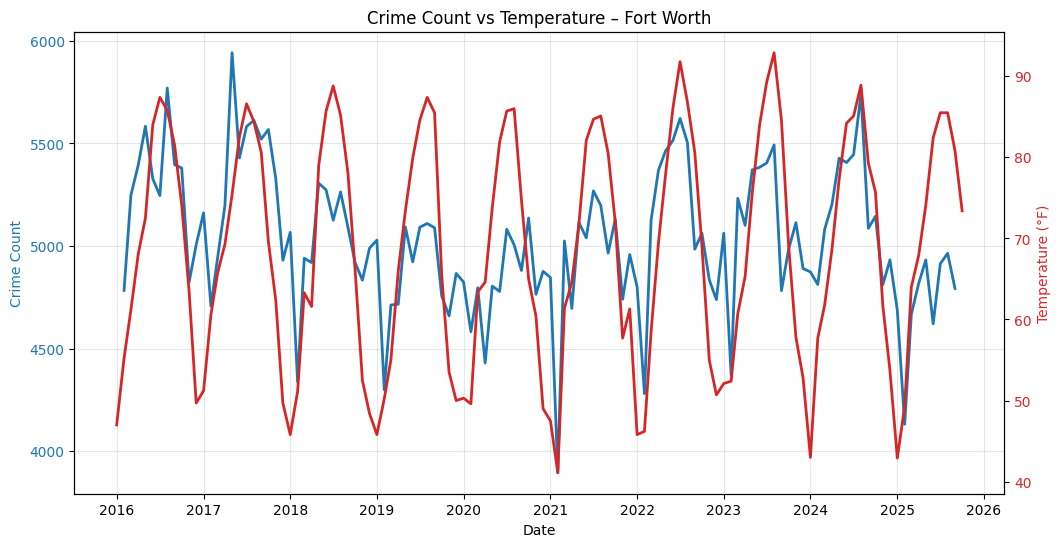

In [42]:
fig, ax1 = plt.subplots(figsize=(12,6))

# --- First Y-axis (Crime) ---
ax1.plot(df2['Date'], df2['Crime_Count'], color='tab:blue', linewidth=2, label='Crime Count')
ax1.set_xlabel('Date')
ax1.set_ylabel('Crime Count', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# --- Second Y-axis (Temperature) ---
ax2 = ax1.twinx()
ax2.plot(df_temp['Date'], df_temp['Temp'], color='tab:red', linewidth=2, label='Temperature (°F)')
ax2.set_ylabel('Temperature (°F)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Title + grid
plt.title('Crime Count vs Temperature – Fort Worth')
ax1.grid(alpha=0.3)

/var/folders/hs/7nqw1trd4wl1z4jpq6rkvq740000gn/T/ipykernel_9920/2556286999.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_temp.resample('M', on='Date')['Temp']


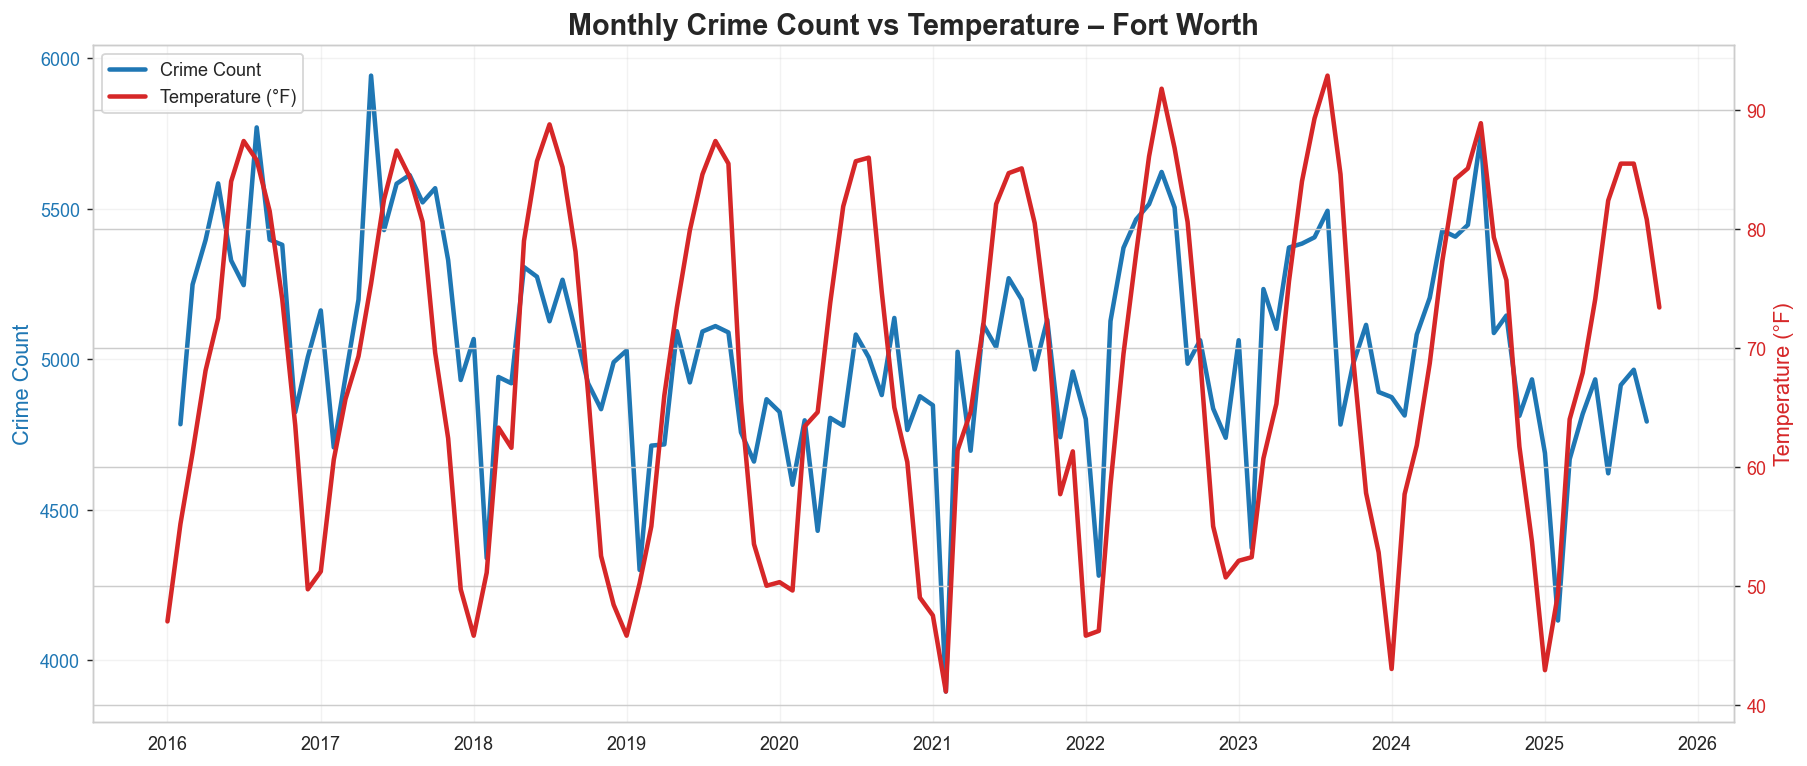

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Ensure temperature is monthly
df_temp_monthly = (
    df_temp.resample('M', on='Date')['Temp']
           .mean()
           .reset_index()
)
df_temp_monthly['Date'] = df_temp_monthly['Date'].dt.to_period('M').dt.to_timestamp()

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(14,6), dpi=130)

# Crime (using df2)
ax1.plot(df2['Date'], df2['Crime_Count'], 
         color='#1f77b4', linewidth=2.5, label='Crime Count')
ax1.set_ylabel('Crime Count', color='#1f77b4', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#1f77b4')

# Temperature — second axis
ax2 = ax1.twinx()
ax2.plot(df_temp_monthly['Date'], df_temp_monthly['Temp'], 
         color='#d62728', linewidth=2.5, label='Temperature (°F)')
ax2.set_ylabel('Temperature (°F)', color='#d62728', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#d62728')

# Title, grid, legend
plt.title("Monthly Crime Count vs Temperature – Fort Worth",
          fontsize=16, weight='bold')

ax1.grid(alpha=0.25)
plt.xticks(rotation=45)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()


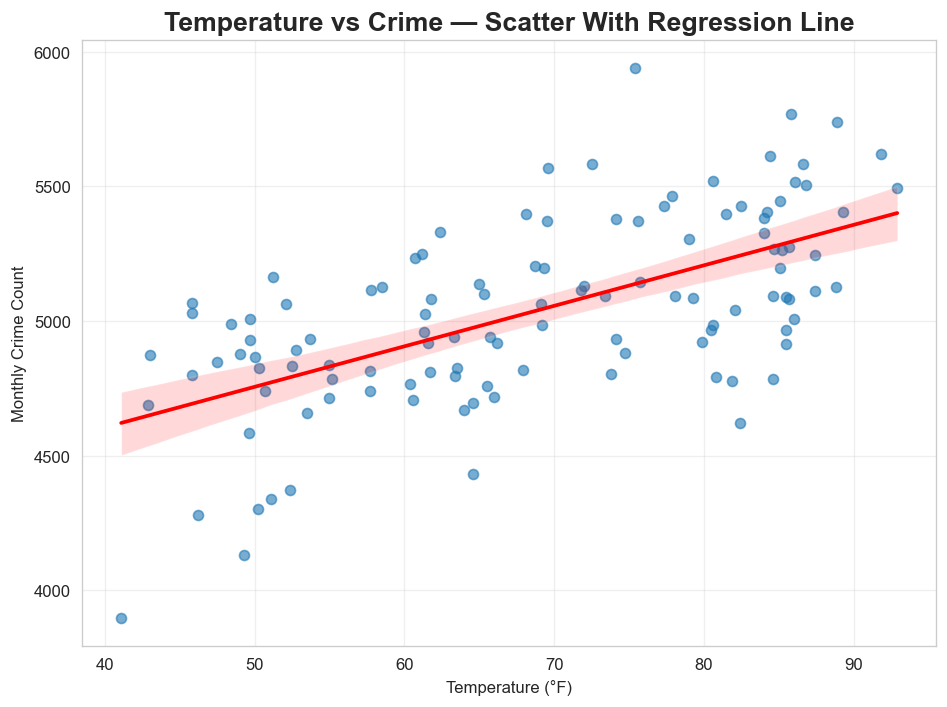

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# Merge df2 and temperature for alignment
merged = df2.merge(df_temp_monthly, on='Date')

plt.figure(figsize=(8,6), dpi=120)
sns.regplot(data=merged, x='Temp', y='Crime_Count',
            scatter_kws={'alpha':0.6}, line_kws={'color':'red'})

plt.title("Temperature vs Crime — Scatter With Regression Line", fontsize=16, weight='bold')
plt.xlabel("Temperature (°F)")
plt.ylabel("Monthly Crime Count")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


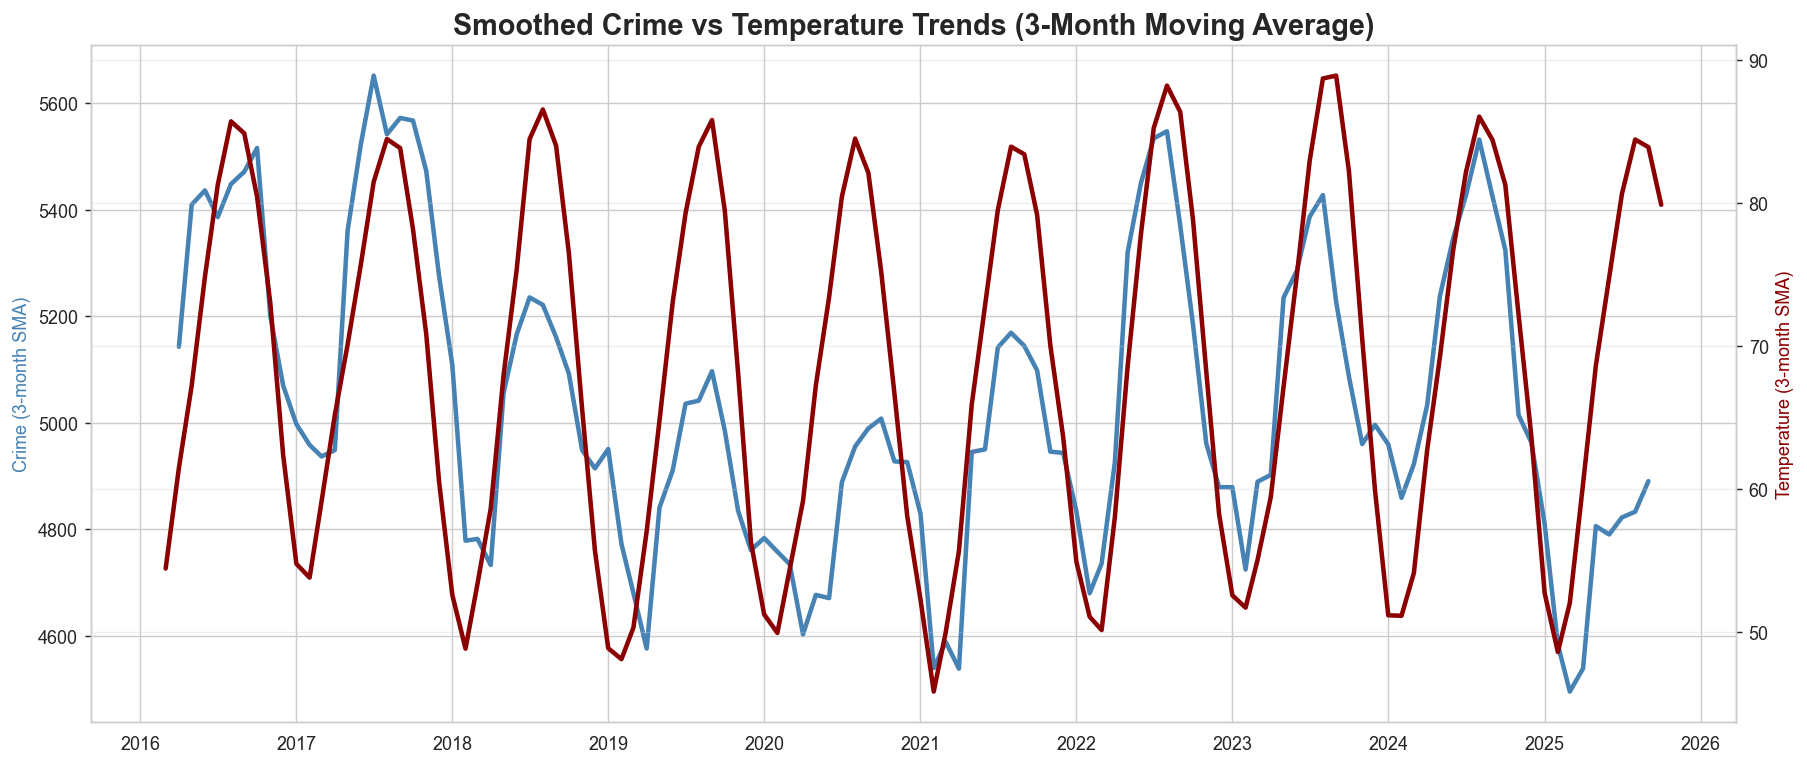

In [45]:
df2['Crime_SMA'] = df2['Crime_Count'].rolling(3).mean()
df_temp_monthly['Temp_SMA'] = df_temp_monthly['Temp'].rolling(3).mean()

fig, ax1 = plt.subplots(figsize=(14,6), dpi=130)

ax1.plot(df2['Date'], df2['Crime_SMA'], color='steelblue', linewidth=2.5)
ax1.set_ylabel("Crime (3-month SMA)", color='steelblue')

ax2 = ax1.twinx()
ax2.plot(df_temp_monthly['Date'], df_temp_monthly['Temp_SMA'], 
         color='darkred', linewidth=2.5)
ax2.set_ylabel("Temperature (3-month SMA)", color='darkred')

plt.title("Smoothed Crime vs Temperature Trends (3-Month Moving Average)", fontsize=16, weight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


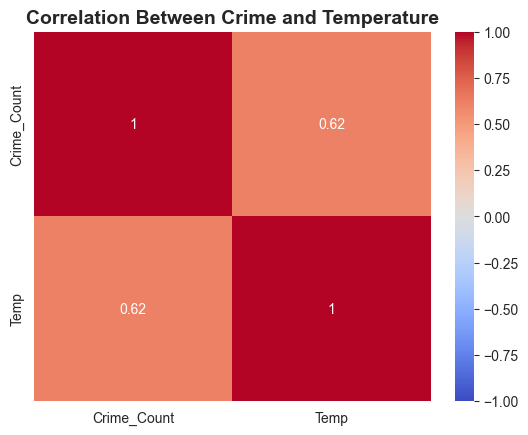

In [46]:
corr = merged[['Crime_Count', 'Temp']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Between Crime and Temperature", fontsize=14, weight='bold')
plt.show()


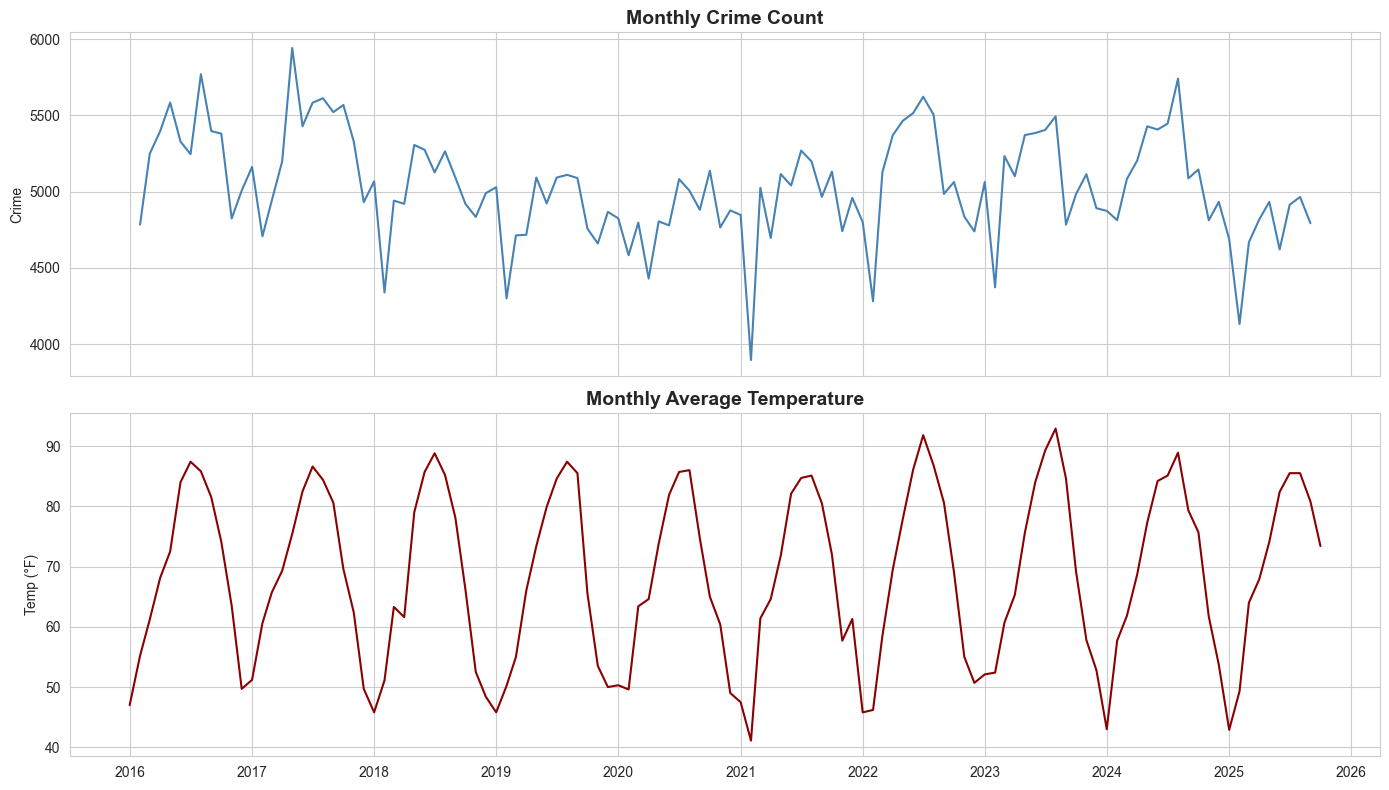

In [48]:
fig, axs = plt.subplots(2, 1, figsize=(14,8), sharex=True)

axs[0].plot(df2['Date'], df2['Crime_Count'], color='steelblue')
axs[0].set_title("Monthly Crime Count", fontsize=14, weight='bold')
axs[0].set_ylabel("Crime")

axs[1].plot(df_temp_monthly['Date'], df_temp_monthly['Temp'], color='darkred')
axs[1].set_title("Monthly Average Temperature", fontsize=14, weight='bold')
axs[1].set_ylabel("Temp (°F)")

plt.tight_layout()
plt.show()


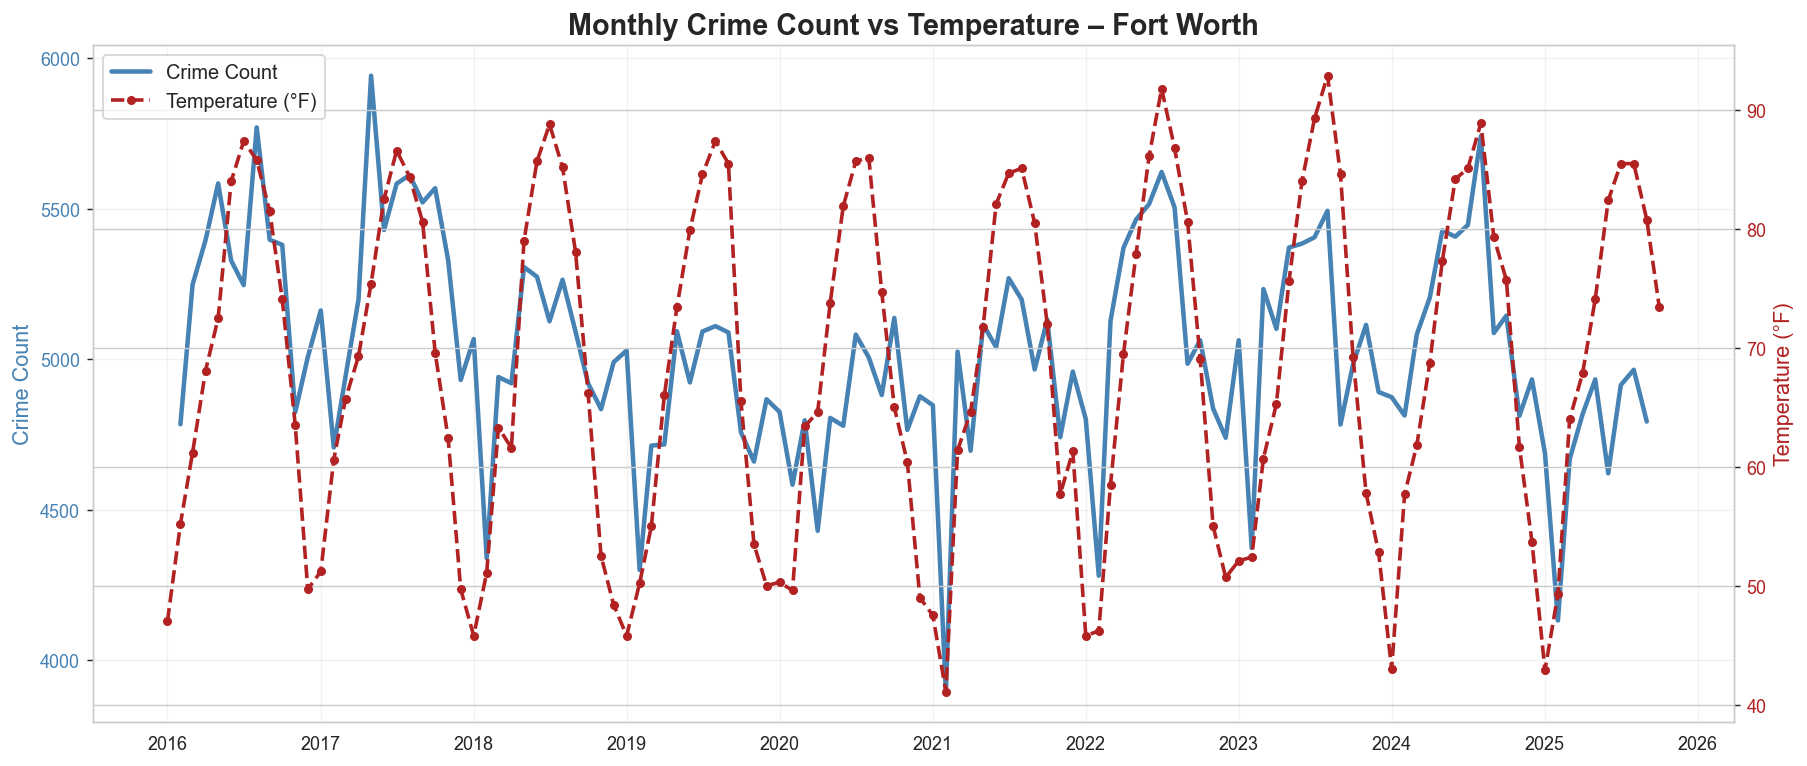

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, ax1 = plt.subplots(figsize=(14,6), dpi=130)

# --- CRIME: Solid Blue Line ---
ax1.plot(
    df2['Date'], df2['Crime_Count'],
    color='steelblue', linewidth=2.5, label='Crime Count'
)
ax1.set_ylabel("Crime Count", color='steelblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')

# --- TEMPERATURE: Dotted Red Line with Markers ---
ax2 = ax1.twinx()
ax2.plot(
    df_temp_monthly['Date'], df_temp_monthly['Temp'],
    color='firebrick', linewidth=2, linestyle='--', marker='o', markersize=4,
    label='Temperature (°F)'
)
ax2.set_ylabel("Temperature (°F)", color='firebrick', fontsize=12)
ax2.tick_params(axis='y', labelcolor='firebrick')

# --- Title, grid, ticks ---
plt.title("Monthly Crime Count vs Temperature – Fort Worth",
          fontsize=16, weight='bold')

ax1.grid(alpha=0.25)
plt.xticks(rotation=45)

# --- Unified Legend ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper left', 
    frameon=True,
    fontsize=11
)

plt.tight_layout()
plt.show()


### Boxcox

In [54]:
import scipy.stats as st

In [55]:
crime = df2['Crime_Count']
lam = st.boxcox_normmax(crime)
print(lam)

2.1002092727851003


<Axes: >

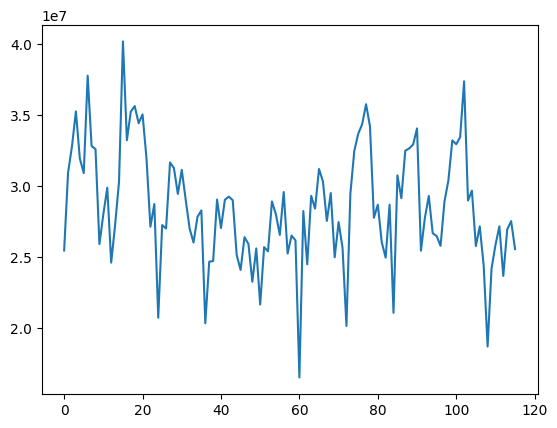

In [56]:
df2['bc'] = st.boxcox(df2['Crime_Count'], lmbda=lam)
df2['bc'].plot()

<Axes: >

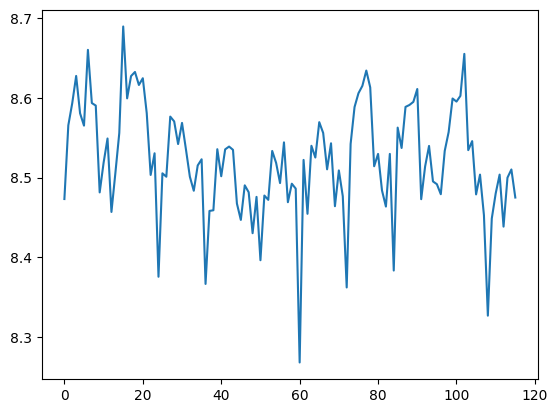

In [57]:
df2['lCrime'] = np.log(df2['Crime_Count'])
df2['lCrime'].plot()